<a href="https://colab.research.google.com/github/tuankhoin/CO3005-PPL/blob/main/Week_5_AST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ho Chi Minh University of Technology (HCMUT)

CO3005 - Principles of Programming Languages

# Week 5 - Abstract Syntax Tree

---

## 1. What is an AST?

### Definition

An **Abstract Syntax Tree (AST)** is a hierarchical tree representation of the **abstract syntactic structure** of source code:
* Removes unnecessary grammar symbols
* Ignores parsing-specific details
* Keeps only semantically meaningful structure

---

### Parse Tree vs AST

| Parse Tree                   | AST                                          |
| ---------------------------- | -------------------------------------------- |
| Contains all grammar symbols | Removes syntactic noise                      |
| Reflects grammar structure   | Reflects program structure                   |
| Used for syntax checking     | Used for semantic analysis & code generation |
| Verbose                      | Compact                                      |

#### Example:

Parse tree:

```
IF <exp> THEN <stmt1> ELSE <stmt2>
```

AST:

```
IfStmt(exp, stmt1, stmt2)
```

AST eliminates keywords like `IF`, `THEN`, `ELSE`.

---

## 2. Example: Expression AST


```html
Grammar:
<exp>  → <exp> + <term> | <term>
<term> → <term> * <fact> | <fact>
<fact> → ( <exp> ) | ID | INT

Expression: 4 * (5 + 3)
```


Parse tree: contains all grammar layers
AST (Scala example):

```scala
BinExp("*", Lit(4), BinExp("+", Lit(5), Lit(3)))
```

AST classes (conceptual form):

```scala
trait Exp
case class BinExp(op:String, e1:Exp, e2:Exp) extends Exp
case class Lit(i:Int) extends Exp
```

Key idea:

* Operators become internal nodes
* Operands become children
* Parentheses disappear


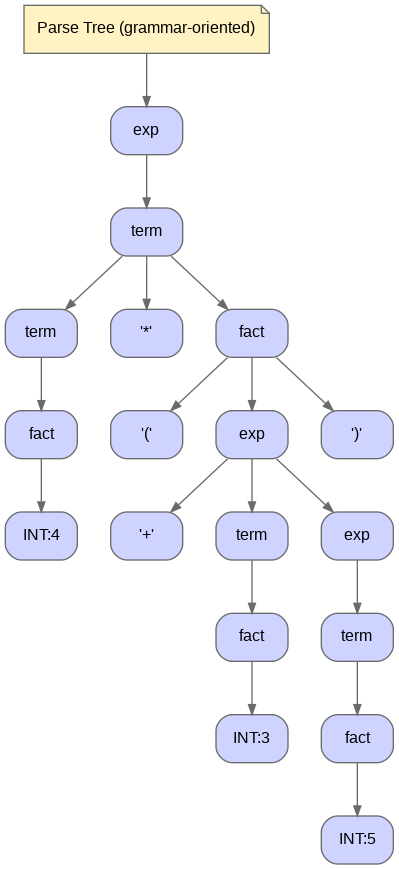
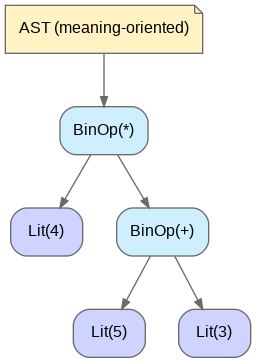

In [ ]:
# @title
# Parse tree vs AST (Graphviz) — self-contained demo for slide 1
# Works in Colab/Jupyter if graphviz is installed (pip install graphviz) and system graphviz exists.

from graphviz import Digraph
from IPython.display import display, HTML
import base64
from pathlib import Path

def make_dot(name: str, title: str):
    dot = Digraph(name=name, format="png")
    dot.attr(rankdir="TB", nodesep="0.35", ranksep="0.55", splines="line")
    dot.attr("node", shape="box", style="rounded,filled",
             fillcolor="#cfd3ff", color="#6a6a6a", fontname="Helvetica", fontsize="12",
             margin="0.14,0.08")
    dot.attr("edge", color="#6a6a6a", arrowsize="0.75")
    dot.node("TITLE", title, shape="note", fillcolor="#fff3c4")
    return dot

def b64_png(path: str) -> str:
    data = Path(path).read_bytes()
    return base64.b64encode(data).decode("ascii")

# -------------------------
# Example expression: 4 * (5 + 3)
# -------------------------

# 1) "Parse tree" (verbose, grammar-oriented)
# Using a typical grammar structure: exp -> term ; term -> term * fact | fact ; fact -> (exp) | INT
pt = make_dot("parse_tree", "Parse Tree (grammar-oriented)")

# Nodes
pt.node("pt_root", "exp")
pt.node("pt_term0", "term")
pt.node("pt_mul_term", "term")
pt.node("pt_mulop", "'*'")
pt.node("pt_fact_paren", "fact")
pt.node("pt_int4", "INT:4")

pt.node("pt_lpar", "'('")
pt.node("pt_exp_in", "exp")
pt.node("pt_term_in", "term")
pt.node("pt_fact5", "fact")
pt.node("pt_int5", "INT:5")
pt.node("pt_addop", "'+'")
pt.node("pt_term_in2", "term")
pt.node("pt_fact3", "fact")
pt.node("pt_int3", "INT:3")
pt.node("pt_rpar", "')'")

# Edges (TITLE at top)
pt.edge("TITLE", "pt_root")

# exp -> term
pt.edge("pt_root", "pt_term0")

# term -> term * fact
pt.edge("pt_term0", "pt_mul_term")
pt.edge("pt_term0", "pt_mulop")
pt.edge("pt_term0", "pt_fact_paren")

# left term -> fact -> INT(4)
pt.node("pt_fact4", "fact")
pt.edge("pt_mul_term", "pt_fact4")
pt.edge("pt_fact4", "pt_int4")

# right fact -> '(' exp ')'
pt.edge("pt_fact_paren", "pt_lpar")
pt.edge("pt_fact_paren", "pt_exp_in")
pt.edge("pt_fact_paren", "pt_rpar")

# inside exp -> exp + term (conceptually)
pt.node("pt_exp_left", "exp")
pt.edge("pt_exp_in", "pt_exp_left")
pt.edge("pt_exp_in", "pt_addop")
pt.edge("pt_exp_in", "pt_term_in2")

# exp_left -> term -> fact -> INT(5)
pt.edge("pt_exp_left", "pt_term_in")
pt.edge("pt_term_in", "pt_fact5")
pt.edge("pt_fact5", "pt_int5")

# term_in2 -> fact -> INT(3)
pt.edge("pt_term_in2", "pt_fact3")
pt.edge("pt_fact3", "pt_int3")


# 2) AST (compact, meaning-oriented)
ast = make_dot("ast_tree", "AST (meaning-oriented)")

ast.node("ast_root", "BinOp(*)", fillcolor="#cfefff")
ast.node("ast_lit4", "Lit(4)")
ast.node("ast_plus", "BinOp(+)", fillcolor="#cfefff")
ast.node("ast_lit5", "Lit(5)")
ast.node("ast_lit3", "Lit(3)")

ast.edge("TITLE", "ast_root")
ast.edge("ast_root", "ast_lit4")
ast.edge("ast_root", "ast_plus")
ast.edge("ast_plus", "ast_lit5")
ast.edge("ast_plus", "ast_lit3")

# Render to files and display side-by-side
pt_path = pt.render("parse_tree_demo", cleanup=True)
ast_path = ast.render("ast_tree_demo", cleanup=True)

pt_b64 = b64_png(pt_path)
ast_b64 = b64_png(ast_path)

display(HTML(f"""
<div style="display:flex; gap:24px; align-items:flex-start;">
  <div style="flex:1;">
    <img src="data:image/png;base64,{pt_b64}" style="max-width:100%; height:auto;">
  </div>
  <div style="flex:1;">
    <img src="data:image/png;base64,{ast_b64}" style="max-width:100%; height:auto;">
  </div>
</div>
"""))


---

## 3. How ANTLR Generates Parse Trees

From grammar (example file name: `BKOOL.g4`) :

```antlr
expr : expr ADD term
     | expr SUB term
     | term ;
```

ANTLR generates:

* `BKOOLParser`
* Context classes:
  * `ExprContext`
  * `TermContext`
  * `FactContext`

Each parser rule → one Context class.

---

## 4. Accessing Children in Parse Tree

From ANTLR generated contexts :

Ways to access children:

```python
ctx.getChild(i)         # Indexing
ctx.getChildCount()     # No. of children
ctx.term(i)             # Field Reference
ctx.term(rule)          # Type (Context Rule)
ctx.getText()           # String representation
ctx.exp()
ctx.ID()
```

If a rule appears multiple times in RHS:

```python
ctx.stmt()        # list
ctx.stmt(i)       # specific child
```


In [ ]:
# @title
# ===============================
# Setup ANTLR4 in Colab/Jupyter
!pip install -U antlr4-tools
!pip install -U antlr4-python3-runtime
!wget -q https://www.antlr.org/download/antlr-4.13.2-complete.jar
!pip freeze | grep antlr4

antlr4-python3-runtime==4.13.2
antlr4-tools==0.2.2


In [ ]:
# @title
# Create grammar file
grammar_code = r"""
grammar Expr;

prog  : expr EOF ;

expr  : term ((ADD | SUB) term)* ;

term  : factor ((MUL | DIV) factor)* ;

factor: INTLIT
      | ID
      | LP expr RP
      ;

ADD : '+' ;
SUB : '-' ;
MUL : '*' ;
DIV : '/' ;
LP  : '(' ;
RP  : ')' ;

INTLIT : [0-9]+ ;
ID     : [a-zA-Z_][a-zA-Z_0-9]* ;
WS     : [ \t\r\n]+ -> skip ;
"""

with open("Expr.g4", "w") as f:
    f.write(grammar_code)



In [ ]:
!java -jar antlr-4.13.2-complete.jar -Dlanguage=Python3 -visitor Expr.g4

In [ ]:
# --- Minimal example grammar (Expr.g4) ---
from antlr4 import InputStream, CommonTokenStream
from ExprLexer import ExprLexer
from ExprParser import ExprParser

# --- Parse an input and get the root context ---
input_text = "4*(5+3)*69+36"
lexer = ExprLexer(InputStream(input_text))
tokens = CommonTokenStream(lexer)
parser = ExprParser(tokens)

tree = parser.prog()   # ProgContext (root)

# --- 3) Slide-4 style child access examples ---
print("Root rule:", type(tree).__name__)
print("Child count of prog:", tree.getChildCount())
print("Children of prog:", [tree.getChild(i).getText() for i in range(tree.getChildCount())])

# Access named sub-rule (since prog : expr EOF ;)
expr_ctx = tree.expr()
print("\nprog.expr():", type(expr_ctx).__name__, "text =", expr_ctx.getText())

# Generic access: getChild(i)
print("expr.getChildCount():", expr_ctx.getChildCount())
print("expr children texts:", [expr_ctx.getChild(i).getText() for i in range(expr_ctx.getChildCount())])

# Access repeated sub-rules:
# expr : term ((ADD|SUB) term)*
print("\nNumber of term() in expr:", len(expr_ctx.term()))
for i, t in enumerate(expr_ctx.term()):
    print(f"  term({i}) =", t.getText())

# Access token nodes by type getters:
# In ANTLR4 Python, tokens like ADD/SUB can be accessed via expr_ctx.ADD() / expr_ctx.SUB()
adds = expr_ctx.ADD()
subs = expr_ctx.SUB()
print("\nADD tokens:", [tok.getText() for tok in adds] if adds else [])
print("SUB tokens:", [tok.getText() for tok in subs] if subs else [])

# Drill into term -> factor (MUL/DIV factor)*
# Find the first term in the expression
t0 = expr_ctx.term(0)
print("\nFirst term text:", t0.getText())
print("term(0) has factors:", [f.getText() for f in t0.factor()])

# factor cases: INTLIT | ID | '(' expr ')'
# Let's grab a nested factor from the second factor of term0, i.e., "(5+3)"
f1 = t0.factor(1)
print("\nSecond factor text:", f1.getText())
print("factor.getChildCount():", f1.getChildCount())
print("factor children:", [f1.getChild(i).getText() for i in range(f1.getChildCount())])

# Access nested expr inside parenthesized factor: factor : LP expr RP
nested_expr = f1.expr()
print("Nested expr type:", type(nested_expr).__name__, "text =", nested_expr.getText())


Root rule: ProgContext
Child count of prog: 2
Children of prog: ['4*(5+3)*69+36', '<EOF>']

prog.expr(): ExprContext text = 4*(5+3)*69+36
expr.getChildCount(): 3
expr children texts: ['4*(5+3)*69', '+', '36']

Number of term() in expr: 2
  term(0) = 4*(5+3)*69
  term(1) = 36

ADD tokens: ['+']
SUB tokens: []

First term text: 4*(5+3)*69
term(0) has factors: ['4', '(5+3)', '69']

Second factor text: (5+3)
factor.getChildCount(): 3
factor children: ['(', '5+3', ')']
Nested expr type: ExprContext text = 5+3





---

## 5. Traversing Parse Tree

ANTLR provides two approaches :

### Listener (Implicit Traversal)

Automatically walks through the parse tree depth-first (post-order traversal). The listener methods are triggered automatically when entering and exiting parse tree nodes.
* Automatic DFS
* Methods: `enterXXX` followed by `exitXXX`
* Good for validation
* Moderate flexibility, simple and fast

### Visitor (Explicit Traversal)

Provides manual control over how nodes are visited in the parse tree, allowing selective traversal of child nodes.
* Manual control
* Method: `visitXXX(ctx)` (Directly returning the value at that node using recursion)
* Good for transformation
* High flexibility, complex and slow

👉 For AST generation → **Use Visitor**


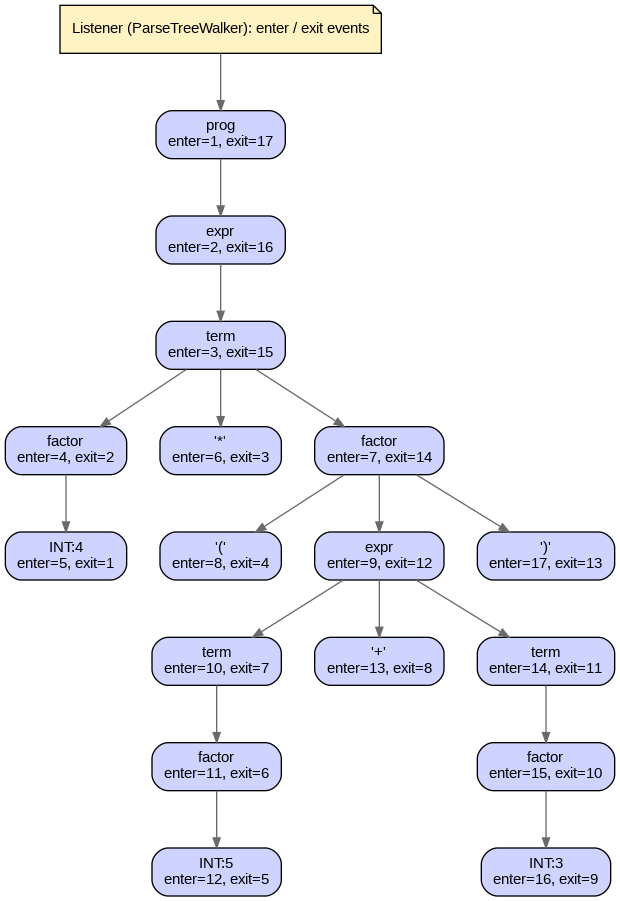
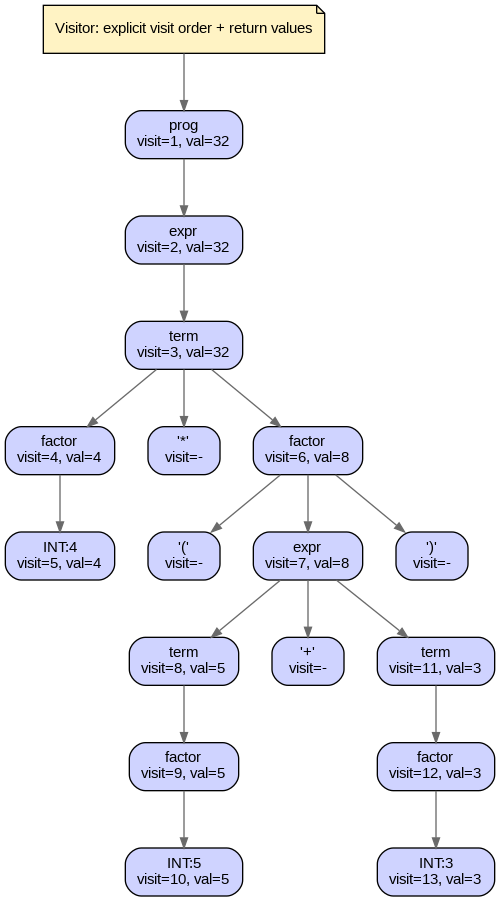

In [ ]:
# @title
# Listener vs Visitor traversal visualization (Graphviz)
# Paste into ONE Colab/Jupyter cell (graphviz installed)

from graphviz import Digraph
from IPython.display import display, HTML
import base64
from pathlib import Path

# -----------------------------
# Build a small parse-tree-like structure for: 4*(5+3)
# (prog -> expr -> term -> factor ...)
# -----------------------------
class Node:
    def __init__(self, label, children=None):
        self.label = label
        self.children = children or []

# A compact parse tree (not every grammar layer, but enough to show traversal)
# prog
#  └ expr
#      └ term
#          ├ factor(INT 4)
#          ├ '*'
#          └ factor( ( expr ) )
#                ├ '('
#                ├ expr
#                │   ├ term(factor(INT 5))
#                │   ├ '+'
#                │   └ term(factor(INT 3))
#                └ ')'

tree = Node("prog", [
    Node("expr", [
        Node("term", [
            Node("factor", [Node("INT:4")]),
            Node("'*'"),
            Node("factor", [
                Node("'('"),
                Node("expr", [
                    Node("term", [Node("factor", [Node("INT:5")])]),
                    Node("'+'"),
                    Node("term", [Node("factor", [Node("INT:3")])]),
                ]),
                Node("')'"),
            ]),
        ])
    ])
])

# -----------------------------
# Traversal logs
# -----------------------------
enter_order = []
exit_order = []

def walk_listener_style(n: Node):
    # Listener "enter"
    enter_order.append(n)
    for c in n.children:
        walk_listener_style(c)
    # Listener "exit"
    exit_order.append(n)

walk_listener_style(tree)

# Visitor style: explicit recursion + return values
visit_order = []
value_map = {}

def eval_visitor(n: Node):
    visit_order.append(n)

    # Minimal evaluation based on labels (just for demo)
    if n.label.startswith("INT:"):
        val = float(n.label.split(":")[1])
        value_map[n] = val
        return val

    # Evaluate meaningful constructs
    if n.label == "factor" and len(n.children) == 1 and n.children[0].label.startswith("INT:"):
        val = eval_visitor(n.children[0])
        value_map[n] = val
        return val

    if n.label == "term":
        # term: factor '*' factor  (in our demo tree)
        if len(n.children) == 3 and n.children[1].label == "'*'":
            left = eval_visitor(n.children[0])
            right = eval_visitor(n.children[2])
            val = left * right
            value_map[n] = val
            return val
        # single factor
        if len(n.children) == 1:
            val = eval_visitor(n.children[0])
            value_map[n] = val
            return val

    if n.label == "expr":
        # expr: term '+' term  (in our demo inner expr)
        if len(n.children) == 3 and n.children[1].label == "'+'":
            left = eval_visitor(n.children[0])
            right = eval_visitor(n.children[2])
            val = left + right
            value_map[n] = val
            return val
        # single term
        if len(n.children) == 1:
            val = eval_visitor(n.children[0])
            value_map[n] = val
            return val

    # Parenthesized factor: factor -> '(' expr ')'
    if n.label == "factor" and len(n.children) == 3 and n.children[0].label == "'('":
        val = eval_visitor(n.children[1])  # expr
        value_map[n] = val
        return val

    # default: evaluate children if any, else None
    if n.children:
        vals = [eval_visitor(c) for c in n.children if c.label not in ("'*'", "'+'", "'('", "')'")]
        val = vals[-1] if vals else None
        value_map[n] = val
        return val

    value_map[n] = None
    return None

final_val = eval_visitor(tree)

# -----------------------------
# Build node ids
# -----------------------------
all_nodes = []
def collect(n):
    all_nodes.append(n)
    for c in n.children:
        collect(c)
collect(tree)

node_id = {n: f"n{i}" for i, n in enumerate(all_nodes)}

# Helper: numbers
enter_idx = {n: i+1 for i, n in enumerate(enter_order)}
exit_idx  = {n: i+1 for i, n in enumerate(exit_order)}
visit_idx = {n: i+1 for i, n in enumerate(visit_order)}

# -----------------------------
# Graphviz rendering
# -----------------------------
def render(dot: Digraph, filename: str) -> str:
    out = dot.render(filename, cleanup=True)
    return out

def b64_png(path: str) -> str:
    data = Path(path).read_bytes()
    return base64.b64encode(data).decode("ascii")

def make_base_dot(title: str):
    dot = Digraph(format="png")
    dot.attr(rankdir="TB", nodesep="0.35", ranksep="0.6", splines="line")
    dot.attr("node", shape="box", style="rounded,filled", fillcolor="#cfd3ff",
             fontname="Helvetica", fontsize="11", margin="0.12,0.08")
    dot.attr("edge", color="#6a6a6a", arrowsize="0.75")
    dot.node("TITLE", title, shape="note", fillcolor="#fff3c4")
    return dot

# Listener graph: label each node with Enter/Exit indices
dotL = make_base_dot("Listener (ParseTreeWalker): enter / exit events")
dotL.edge("TITLE", node_id[tree])

for n in all_nodes:
    label = f"{n.label}\nenter={enter_idx[n]}, exit={exit_idx[n]}"
    dotL.node(node_id[n], label)

for n in all_nodes:
    for c in n.children:
        dotL.edge(node_id[n], node_id[c])

# Visitor graph: label each node with visit index + (optional) computed value
dotV = make_base_dot("Visitor: explicit visit order + return values")
dotV.edge("TITLE", node_id[tree])

for n in all_nodes:
    v = value_map.get(n, None)
    vtxt = "" if v is None else f", val={v:g}"
    label = f"{n.label}\nvisit={visit_idx.get(n, '-')}{vtxt}"
    dotV.node(node_id[n], label)

for n in all_nodes:
    for c in n.children:
        dotV.edge(node_id[n], node_id[c])

# Render and show side-by-side
pL = render(dotL, "listener_traversal")
pV = render(dotV, "visitor_traversal")

bL = b64_png(pL)
bV = b64_png(pV)

display(HTML(f"""
<div style="display:flex; gap:18px; align-items:flex-start;">
  <div style="flex:1;">
    <img src="data:image/png;base64,{bL}" style="max-width:100%; height:auto;">
  </div>
  <div style="flex:1;">
    <img src="data:image/png;base64,{bV}" style="max-width:100%; height:auto;">
  </div>
</div>
<p><b>Visitor final value:</b> {final_val:g}</p>
"""))


---

## 6. Visitor Pattern (Core Idea)

Visitor pattern allows **adding new operations without modifying element classes**

### 6.1 Components

**Element**

* Has `accept(visitor)`

**Visitor**

* Has `visit<ElementType>(...)`

### 6.2 Professional Visitor Design

Instead of:

```python
if type(ctx) is A:
  ...
elif type(ctx) is B:
  ...
elif type(ctx) is C:
  ...
# continues to if-else until death...
```

<img src="https://github.com/tuankhoin/CO3005-PPL/blob/main/assets/dllt_disapprove.png?raw=true" alt="drawing" width="200"/>

Use double dispatch:

```python
class Visitor:
    # Visitor will handle each type differently
    def visit(self, ctx: ParentClass):
        return ctx.accept(self)

############################

class A(ParentClass):
    # Each class will have a different interaction when visited
    def accept(self, v: Visitor):
        return v.visitA(self)

class B(ParentClass): ...

class C(ParentClass): ...

############################

class VisitorCompilationClass(Visitor):
  def visitA(self, ctx: A):
    ...

  # define visitB, visitC,...
```

Cleaner, extensible, maintainable.

In [ ]:
from abc import ABC, abstractmethod
from __future__ import annotations

# Base element
class RiCon(ABC):
    @abstractmethod
    def accept(self, visitor: RiConVisitor):
        pass

In [ ]:
# Concrete elements
class PiersMorgan(RiCon):
    def accept(self, visitor):
        return visitor.visitPiersMorgan(self)

class Messi(RiCon):
    def accept(self, visitor):
        return visitor.visitMessi(self)

class RealMadrid(RiCon):
    def accept(self, visitor):
        return visitor.visitRealMadrid(self)

class WorldCup(RiCon):
    def accept(self, visitor):
        return visitor.visitWorldCup(self)

class ManUnited(RiCon):
    def accept(self, visitor):
        return visitor.visitManUnited(self)

class Instagram(RiCon):
    def accept(self, visitor):
        return visitor.visitInstagram(self)


In [ ]:
# Base Visitor Class
class RiConVisitor(ABC):

    @abstractmethod
    def visitPiersMorgan(self, obj: PiersMorgan) -> None:
        pass

    @abstractmethod
    def visitMessi(self, obj: Messi) -> None:
        pass

    @abstractmethod
    def visitRealMadrid(self, obj: RealMadrid) -> None:
        pass

    @abstractmethod
    def visitWorldCup(self, obj: WorldCup) -> None:
        pass

    @abstractmethod
    def visitManUnited(self, obj: ManUnited) -> None:
        pass

    @abstractmethod
    def visitInstagram(self, obj: Instagram) -> None:
        pass

In [ ]:
# Concrete Visitor Classes
class RonaldoVisitor(RiConVisitor):

    def visitPiersMorgan(self, obj: PiersMorgan) -> None:
        print("Chief of RiCons")

    def visitMessi(self, obj: Messi) -> None:
        print("si lùn trốn thuế")

    def visitRealMadrid(self, obj: RealMadrid) -> None:
        print("Camel Cup is the best cup")

    def visitWorldCup(self, obj: WorldCup) -> None:
        print("Messi = No Euro")

    def visitManUnited(self, obj: ManUnited) -> None:
        print("-1")

    def visitInstagram(self, obj: Instagram) -> None:
        print("Factos 👀👍🏻")


In [ ]:
ricons = [
    PiersMorgan(),
    Messi(),
    RealMadrid(),
    WorldCup(),
    ManUnited(),
    Instagram()
]

visitor: RiConVisitor = RonaldoVisitor()

for item in ricons:
    print(f'RiCon is visiting {item.__class__.__name__}. RiCon says:', end=' ')
    item.accept(visitor)
    print()

RiCon is visiting PiersMorgan. RiCon says: Chief of RiCons

RiCon is visiting Messi. RiCon says: si lùn trốn thuế

RiCon is visiting RealMadrid. RiCon says: Camel Cup is the best cup

RiCon is visiting WorldCup. RiCon says: Messi = No Euro

RiCon is visiting ManUnited. RiCon says: -1

RiCon is visiting Instagram. RiCon says: Factos 👀👍🏻





---

## 7. Using Visitor in ANTLR

ANTLR (with `-visitor` option) generates:

```
ClassVisitor.py
BaseClassVisitor.py
```

Each parser rule: `visit<Rule>`

```
visitExp(ctx)
visitTerm(ctx)
visitAssign(ctx)
```

To build AST:

* Inherit from `BaseVisitor`
* Override visit methods
* Construct AST nodes

---

## 8. Writing AST Generation

1. Implement simple rules first (bottom-up).
2. Each grammar alternative → one case in `visit` method.
3. Call `visit` for non-terminals.
4. Only process **direct children**, not grandchildrens and after.
5. Create AST node **immediately** when enough data exists.

---


## 9. AST Example

Grammar

```antlr
expr   : term (ADD term)* ;
term   : factor (MUL factor)* ;
factor : INTLIT
       | ID
       | LP expr RP
       ;
```

Example expression:

```
4 * (5 + 3)
```

### Step 1 — Decide Order (Bottom-up)

```
factor  → term  → expr
```


### Step 2 — Form Corresponding `visitX` Methods

#### `visitFactor`

Grammar:

```antlr
factor : INTLIT
       | ID
       | LP expr RP
```

Implementation:

```python
def visitFactor(self, ctx):
    if ctx.INTLIT():
        return Num(int(ctx.INTLIT().getText()))

    if ctx.ID():
        return Var(ctx.ID().getText())

    # '(' expr ')'
    return self.visit(ctx.expr())
```

#### `visitTerm`

Grammar:

```antlr
term : factor (MUL factor)* ;
```

Implementation:

```python
def visitTerm(self, ctx):
    node = self.visit(ctx.factor(0))

    for i in range(len(ctx.MUL())):
        op = ctx.MUL(i).getText()
        right = self.visit(ctx.factor(i + 1))
        node = BinOp(op, node, right)

    return node
```

#### `visitExpr`

Grammar:

```antlr
expr : term (ADD term)* ;
```

Implementation:

```python
def visitExpr(self, ctx):
    node = self.visit(ctx.term(0))

    for i in range(len(ctx.ADD())):
        op = ctx.ADD(i).getText()
        right = self.visit(ctx.term(i + 1))
        node = BinOp(op, node, right)

    return node
```

### Step 3 — Identify Non-Terminals

Non-terminals in grammar:

```
expr, term, factor
```

Therefore:

* In `visitExpr` → call `visit(ctx.term(i))`
* In `visitTerm` → call `visit(ctx.factor(i))`
* In `visitFactor` → call `visit(ctx.expr())`

We **never** manually inspect grandchildren like:

```
ctx.factor(0).INTLIT()
```

### Step 4: Form AST

1. `visitFactor(4)`, `visitFactor(3)`, `visitFactor(5)`
  ```css
  Num(4) * ( Num(5) + Num(3) )
  ```
2. `visitExpr( (Num(5)+Num(3) )`
```css
Num(4) * BinOp("+", Num(5), Num(3))
```
3. `visitTerm(Num(4) * BinOp("+", Num(5), Num(3)))`
```css
BinOp("*", Num(4), BinOp("+", Num(5), Num(3)))
```
### Resulting AST for 4*(5+3)



```
        *
       / \
      4   +
         / \
        5   3
```
---

## More good ANTLR Resources
- https://tomassetti.me/antlr-mega-tutorial/
- http://bearcave.com/software/antlr/antlr_examples.html